***
# <font color=green size=10>**DS-04 - ANÁLISES BÁSICAS DE DADOS PARA ÁREA DA SAÚDE II - AULA 03**</font>
***

## <font color=green size=6>**ÁRVORE DE DECISÃO - REGRESSÃO**</font>

# <font color=green size=6>**Exercício Prático com DecisionTreeRegressor**</font>

#Neste exercício, vamos utilizar a base de dados "Breast Cancer" para construir um modelo de árvore de regressão.

# As etapas incluem:

# 1. Carregar a base de dados
# 2. Pré-processamento (eliminar colunas e valores faltantes, transformar variáveis categóricas)
# 3. Dividir a base de dados em treino e teste
# 4. Criar e treinar o modelo DecisionTreeRegressor
# 5. Plotar a árvore de decisão
# 6. Avaliar o modelo usando MAE e MSE
# 7. Verificar a correlação entre as variáveis
# 8. Criação de uma árvore otimizada selecionando apenas 04 variáveis independentes
# 9. Criação de outras duas árvores: 1- a mesma árvores do passo 4 e; 2 - a mesma árvore do passo 8. Porém, ambas com profundidade máxima igual a 4.


# <font color=green size=6>**Vamos Começar?**</font>

# 1 -Vamos usar a base de dados "Breast Cancer" do sklearn.

In [3]:
# 1. Carregar a base de dados
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Carrega a base de dados
data = load_breast_cancer()


# 2 - Vamos verificar valores faltantes e transformar variáveis categóricas em numéricas, se necessário.


In [5]:
# 2. Pré-processamento
# Converte o array NumPy para um DataFrame do Pandas para facilitar o tratamento de valores ausentes
df = pd.DataFrame(data.data, columns=data.feature_names)

print(df.isnull().sum())  # Agora você pode verificar se há valores ausentes

# Verificar se há variáveis categóricas
print(data.feature_names)

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'm

# 3 - Dividir a base de dados em treino e teste

In [6]:
# 3. Dividir a base de dados em treino e teste

from sklearn.model_selection import train_test_split

# Divide os dados em conjuntos de treinamento e teste
X = df  # Variáveis independentes
y = data.target  # Variável dependente (target)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 4 - Vamos criar e treinar a árvore de regressão utilizando a base de dados de treino.

In [7]:
# 4. Treinar o modelo DecisionTreeRegressor

from sklearn.tree import DecisionTreeRegressor
# Cria o modelo de árvore de decisão
model = DecisionTreeRegressor()

# Treina o modelo
model.fit(X_train, y_train)


DecisionTreeRegressor()

# 5 - Vamos plotar a árvore de decisão para visualizar como o modelo está tomando decisões.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.


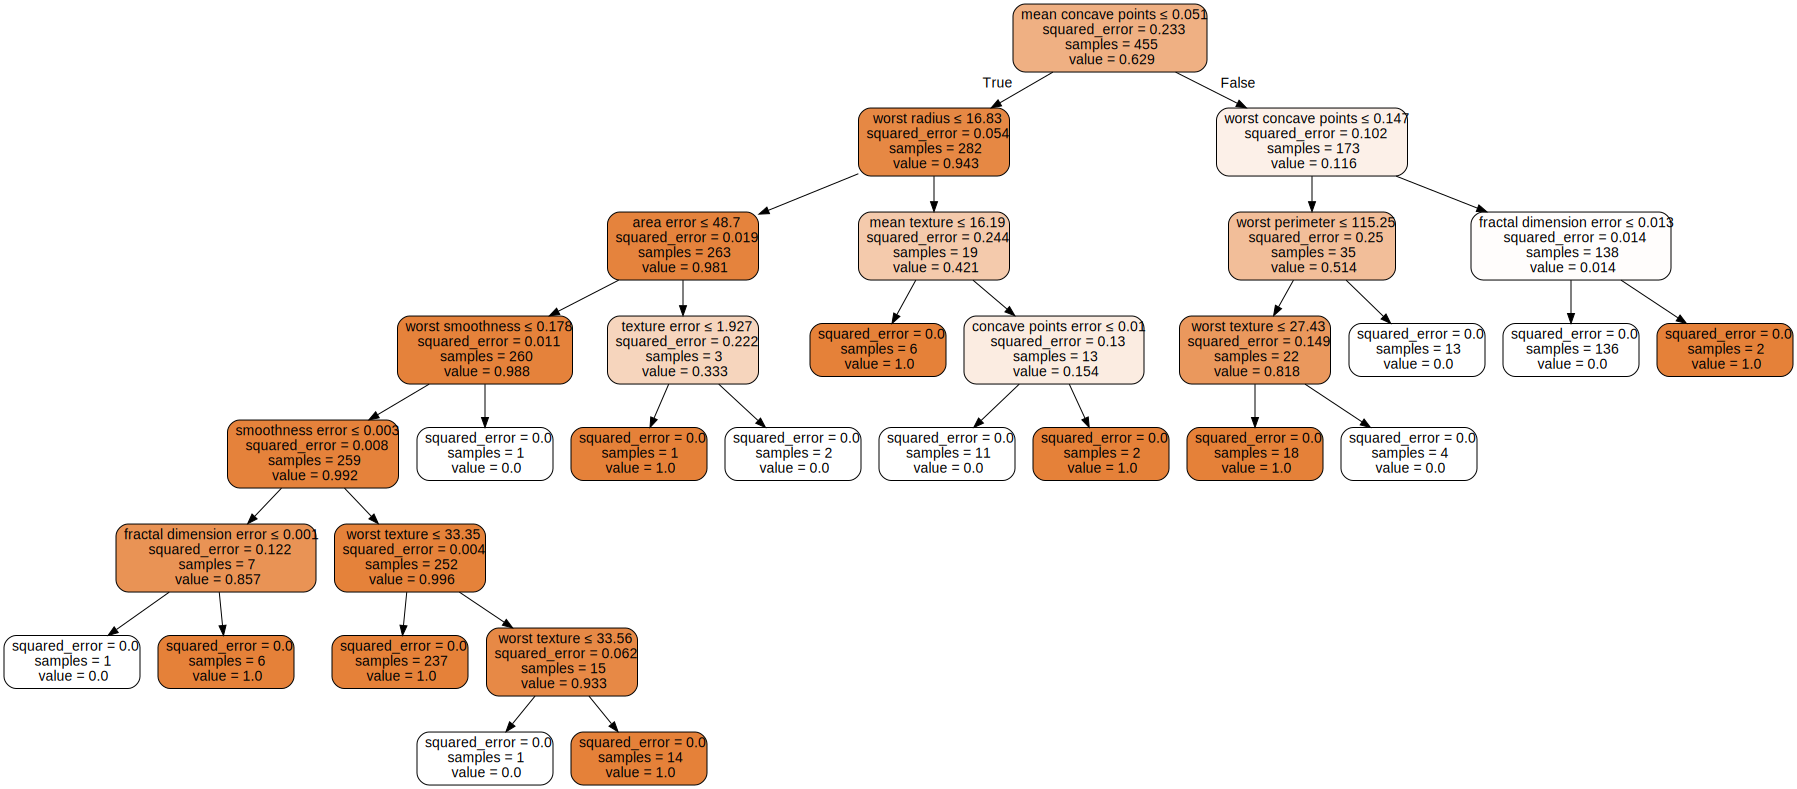

In [8]:
# 5. Plotar a árvore de decisão

!pip install graphviz
!apt-get install graphviz

from sklearn.tree import export_graphviz
import graphviz

# Exporta a árvore de decisão para um arquivo .dot
dot_data = export_graphviz(model, out_file=None,
                         feature_names=data.feature_names,
                         filled=True, rounded=True,
                         special_characters=True)

# Cria o gráfico a partir do arquivo .dot
graph = graphviz.Source(dot_data)

# Renderiza o gráfico em um arquivo PDF
graph.render("decision_tree")

# Exibe o gráfico
graph


# 6 - Vamos calcular os valores de MAE (Mean Absolute Error) e MSE (Mean Squared Error) para avaliar a performance do modelo.

In [9]:
# 6. Avaliar o modelo usando MAE e MSE

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Faz previsões no conjunto de teste
y_pred = model.predict(X_test)

# Calcula o MAE
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

# Calcula o MSE
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)


MAE: 0.06140350877192982
MSE: 0.06140350877192982


# 7 - Vamos verificar a correlação entre as variáveis para entender quais são mais importantes para o modelo.

In [10]:
# 7. Verificar a correlação entre as variáveis

# Calcula a matriz de correlação
correlation_matrix = df.corr()

# Exibe a matriz de correlação
print(correlation_matrix)


                         mean radius  mean texture  mean perimeter  mean area  \
mean radius                 1.000000      0.323782        0.997855   0.987357   
mean texture                0.323782      1.000000        0.329533   0.321086   
mean perimeter              0.997855      0.329533        1.000000   0.986507   
mean area                   0.987357      0.321086        0.986507   1.000000   
mean smoothness             0.170581     -0.023389        0.207278   0.177028   
mean compactness            0.506124      0.236702        0.556936   0.498502   
mean concavity              0.676764      0.302418        0.716136   0.685983   
mean concave points         0.822529      0.293464        0.850977   0.823269   
mean symmetry               0.147741      0.071401        0.183027   0.151293   
mean fractal dimension     -0.311631     -0.076437       -0.261477  -0.283110   
radius error                0.679090      0.275869        0.691765   0.732562   
texture error              -

# 8 - Agora crie uma nova árvore utilizando somente as 4 variáveis, que você julgar, mais importantes e compare o resultado com a árvore anterior. E responda se o modelo com 4 variáveis foi mais eficiente que o modelo anterior?

In [11]:
# Criar Nova base de dados

# Seleciona as 4 variáveis mais importantes (substitua com as suas escolhas)
selected_features = ['worst perimeter', 'worst area', 'mean concave points', 'worst concave points']

# Cria um novo DataFrame com as variáveis selecionadas
X_selected = df[selected_features]

# Divide os dados em conjuntos de treinamento e teste
X_train_selected, X_test_selected, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Cria um novo modelo de árvore de decisão
model_selected = DecisionTreeRegressor()

# Treina o novo modelo
model_selected.fit(X_train_selected, y_train)

# Faz previsões no conjunto de teste
y_pred_selected = model_selected.predict(X_test_selected)

# Calcula o MAE para o modelo com variáveis selecionadas
mae_selected = mean_absolute_error(y_test, y_pred_selected)
print("MAE (modelo com variáveis selecionadas):", mae_selected)

# Calcula o MSE para o modelo com variáveis selecionadas
mse_selected = mean_squared_error(y_test, y_pred_selected)
print("MSE (modelo com variáveis selecionadas):", mse_selected)

# Compara os resultados com o modelo anterior
print("Comparação de MAE:")
print("MAE (modelo original):", mae)
print("MAE (modelo com variáveis selecionadas):", mae_selected)

print("\nComparação de MSE:")
print("MSE (modelo original):", mse)
print("MSE (modelo com variáveis selecionadas):", mse_selected)

# Avalia se o modelo com 4 variáveis foi mais eficiente
if mae_selected < mae and mse_selected < mse:
  print("\nO modelo com 4 variáveis foi mais eficiente.")
elif mae_selected > mae and mse_selected > mse:
  print("\nO modelo original foi mais eficiente.")
else:
  print("\nNão há uma diferença significativa na eficiência dos modelos.")


MAE (modelo com variáveis selecionadas): 0.06140350877192982
MSE (modelo com variáveis selecionadas): 0.06140350877192982
Comparação de MAE:
MAE (modelo original): 0.06140350877192982
MAE (modelo com variáveis selecionadas): 0.06140350877192982

Comparação de MSE:
MSE (modelo original): 0.06140350877192982
MSE (modelo com variáveis selecionadas): 0.06140350877192982

Não há uma diferença significativa na eficiência dos modelos.


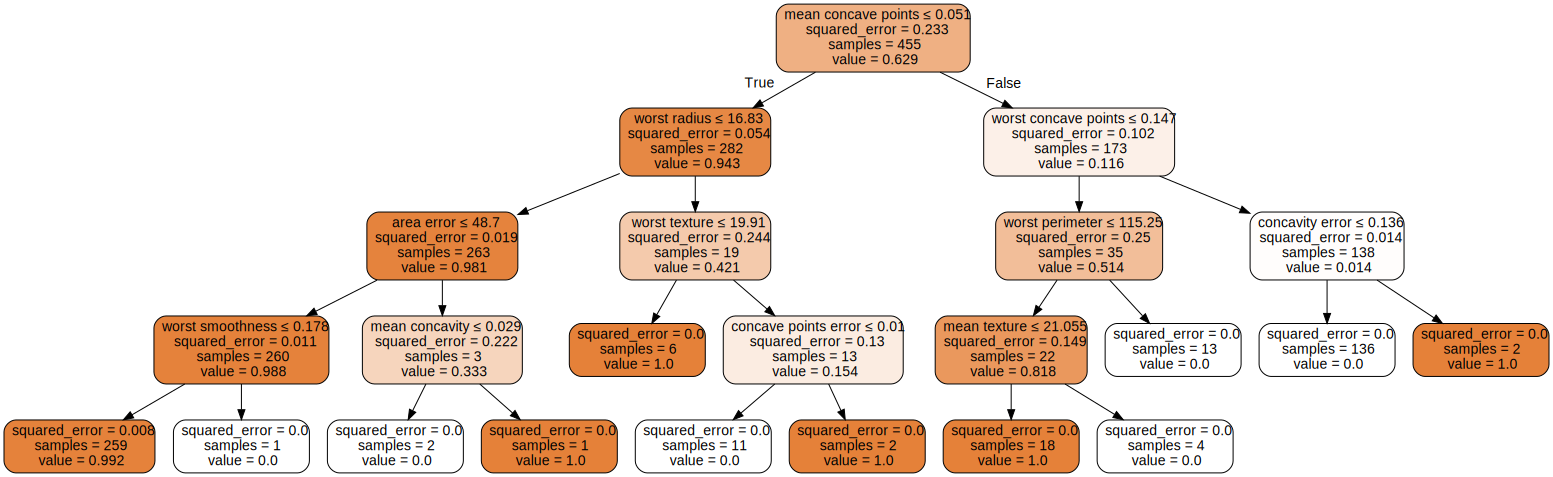

In [12]:
# Dividir a base de dados

# Divide os dados em conjuntos de treinamento e teste (se ainda não estiverem divididos)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Cria o modelo de árvore de decisão com profundidade máxima 4
model_depth4 = DecisionTreeRegressor(max_depth=4)

# Treina o modelo
model_depth4.fit(X_train, y_train)

# Plota a árvore de decisão
dot_data_depth4 = export_graphviz(model_depth4, out_file=None,
                                feature_names=data.feature_names,
                                filled=True, rounded=True,
                                special_characters=True)
graph_depth4 = graphviz.Source(dot_data_depth4)
graph_depth4.render("decision_tree_depth4")
graph_depth4


In [13]:
# Avaliar o modelo

# Faz previsões no conjunto de teste
y_pred_depth4 = model_depth4.predict(X_test)

# Calcula o MAE
mae_depth4 = mean_absolute_error(y_test, y_pred_depth4)
print("MAE (profundidade 4):", mae_depth4)

# Calcula o MSE
mse_depth4 = mean_squared_error(y_test, y_pred_depth4)
print("MSE (profundidade 4):", mse_depth4)


MAE (profundidade 4): 0.056695793537898796
MSE (profundidade 4): 0.052394107464215155


# 9 - Por fim, crie as últimas duas árvores: 1- a mesma árvores do passo 4 e; 2 - a mesma árvore do passo 8. Porém, ambas com profundidade máxima igual a 4.


In [14]:
# Cria o modelo de árvore de decisão com profundidade máxima 4 (usando todas as variáveis)
model_all_depth4 = DecisionTreeRegressor(max_depth=4)

# Treina o modelo
model_all_depth4.fit(X_train, y_train)

# Plota a árvore de decisão
dot_data_all_depth4 = export_graphviz(model_all_depth4, out_file=None,
                                feature_names=data.feature_names,
                                filled=True, rounded=True,
                                special_characters=True)
graph_all_depth4 = graphviz.Source(dot_data_all_depth4)
graph_all_depth4.render("decision_tree_all_depth4")
graph_all_depth4

# Faz previsões no conjunto de teste
y_pred_all_depth4 = model_all_depth4.predict(X_test)

# Calcula o MAE
mae_all_depth4 = mean_absolute_error(y_test, y_pred_all_depth4)
print("MAE (todas as variáveis, profundidade 4):", mae_all_depth4)

# Calcula o MSE
mse_all_depth4 = mean_squared_error(y_test, y_pred_all_depth4)
print("MSE (todas as variáveis, profundidade 4):", mse_all_depth4)

# Cria o modelo de árvore de decisão com profundidade máxima 4 (usando as variáveis selecionadas)
model_selected_depth4 = DecisionTreeRegressor(max_depth=4)

# Treina o modelo
model_selected_depth4.fit(X_train_selected, y_train)

# Plota a árvore de decisão
dot_data_selected_depth4 = export_graphviz(model_selected_depth4, out_file=None,
                                feature_names=selected_features,
                                filled=True, rounded=True,
                                special_characters=True)
graph_selected_depth4 = graphviz.Source(dot_data_selected_depth4)
graph_selected_depth4.render("decision_tree_selected_depth4")
graph_selected_depth4

# Faz previsões no conjunto de teste
y_pred_selected_depth4 = model_selected_depth4.predict(X_test_selected)

# Calcula o MAE
mae_selected_depth4 = mean_absolute_error(y_test, y_pred_selected_depth4)
print("MAE (variáveis selecionadas, profundidade 4):", mae_selected_depth4)

# Calcula o MSE
mse_selected_depth4 = mean_squared_error(y_test, y_pred_selected_depth4)
print("MSE (variáveis selecionadas, profundidade 4):", mse_selected_depth4)



MAE (todas as variáveis, profundidade 4): 0.07417191627717941
MSE (todas as variáveis, profundidade 4): 0.0699374440483971
MAE (variáveis selecionadas, profundidade 4): 0.0989445646078667
MSE (variáveis selecionadas, profundidade 4): 0.06567416846728905
